In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet("../data/processed/NCRP_1991_2020.parquet")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (13897856, 18)


,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,EDUCATION,ADMITYR,RELEASEYR,MAND_PRISREL_YEAR,PROJ_PRISREL_YEAR,PARELIG_YEAR,SENTLGTH,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE
0,A012021000000090128,1,1,2,9,2013,2013,9999,9999,9999,4,8,1,5,5,0,3,1
1,A012021000000110168,1,1,1,9,2004,9999,9999,9999,9999,4,3,1,5,9,9,9,1
2,A012021000000090187,1,1,2,9,2009,2009,9999,9999,9999,0,11,9,1,1,0,1,1
3,A012021000000010425,1,3,3,9,2016,2016,9999,9999,9999,2,12,9,3,3,0,3,1
4,A012021000000090117,1,1,1,9,2009,2017,9999,9999,9999,4,4,9,1,2,3,1,1


In [3]:
# 9999 is clearly used as a sentinel (visible in MAND_PRISREL_YEAR, RELEASEYR etc.)
# 9 is used in single-digit fields (AGERELEASE=9, RELTYPE=9, RACE=9)

# Year columns: 9999 = unknown
year_cols_with_sentinels = ["RELEASEYR", "MAND_PRISREL_YEAR", "PROJ_PRISREL_YEAR", "PARELIG_YEAR"]
df[year_cols_with_sentinels] = df[year_cols_with_sentinels].replace(9999, pd.NA)

# Single-digit sentinel columns where 9 cannot be a real value
df["RELTYPE"] = df["RELTYPE"].replace(9, pd.NA)
df["RACE"] = df["RACE"].replace(9, pd.NA)
df["AGERELEASE"] = df["AGERELEASE"].replace(9, pd.NA)

In [4]:
dtype_map = {
    "ABT_INMATE_ID": "object",     # anonymized string ID
    "SEX": "category",             # 1=Male, 2=Female
    "RACE": "category",            # coded race/ethnicity — see codebook note on undercounting
    "STATE": "category",           # FIPS codes, not real numbers
    "ADMTYPE": "category",         # type of admission
    "RELTYPE": "category",         # type of release
    "OFFGENERAL": "category",      # 5-level offense category
    "OFFDETAIL": "category",       # detailed offense category
    # EDUCATION dropped: entirely coded 9 across all 13.9M rows — unusable
    "AGEADMIT": "Int16",           # age in years
    "AGERELEASE": "Int16",         # age in years
    "TIMESRVD": "Int32",           # time served
    "SENTLGTH": "Int32",           # sentence length
    "ADMITYR": "Int16",            # 1991-2020
    "RELEASEYR": "Int16",
    # MAND_PRISREL_YEAR dropped: 61% missing
    # PROJ_PRISREL_YEAR dropped: 47% missing
    # PARELIG_YEAR dropped: 75% missing
}

# Drop columns before casting to avoid errors on columns being removed
cols_to_drop = ["EDUCATION", "PARELIG_YEAR", "MAND_PRISREL_YEAR", "PROJ_PRISREL_YEAR"]
df.drop(columns=cols_to_drop, inplace=True)

df = df.astype(dtype_map)
print("Dtypes after casting:")
print(df.dtypes)

Dtypes after casting:
ABT_INMATE_ID      object
SEX              category
ADMTYPE          category
OFFGENERAL       category
ADMITYR             Int16
RELEASEYR           Int16
SENTLGTH            Int32
OFFDETAIL        category
RACE             category
AGEADMIT            Int16
AGERELEASE          Int16
TIMESRVD            Int32
RELTYPE          category
STATE            category
dtype: object


In [5]:
# Missingness audit
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Missing values (%):")
print(missing[missing > 0].round(2))

Missing values (%):
RELTYPE       11.85
RACE           9.49
AGERELEASE     7.51
RELEASEYR      7.17
dtype: float64


In [6]:
# Key column distributions
print("--- ADMITYR ---")
print(df["ADMITYR"].value_counts().sort_index())

print("\n--- RELEASEYR ---")
print(df["RELEASEYR"].value_counts().sort_index())

print(f"\nUnique states: {df['STATE'].nunique()}")
print(df["STATE"].value_counts().sort_index())

for col in ["SEX", "RACE", "ADMTYPE", "RELTYPE", "OFFGENERAL"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

--- ADMITYR ---
ADMITYR
1950        16
1951        21
1952        29
1953        21
1954        30
         ...  
2017    521118
2018    506155
2019    452286
2020    262397
9999       658
Name: count, Length: 72, dtype: Int64

--- RELEASEYR ---
RELEASEYR
1971      3604
1972      5411
1973      5224
1974      5893
1975      6316
1976      6136
1977      6674
1978      7349
1979      6179
1980      7936
1981      8038
1982      8856
1983     10943
1984     11513
1985     11975
1986     12722
1987     14203
1988     13193
1989     42622
1990     59388
1991     62284
1992    147900
1993    150547
1994    194807
1995    207253
1996    240465
1997    252514
1998    268709
1999    298894
2000    365691
2001    379108
2002    393513
2003    420749
2004    448707
2005    539186
2006    568435
2007    596154
2008    611278
2009    641718
2010    623037
2011    605536
2012    542220
2013    530937
2014    530726
2015    534736
2016    525867
2017    531039
2018    525019
2019    481116
2020    4

In [7]:
# Recidivism identification
# ABT_INMATE_ID links the same person across multiple spells
# This is the foundation of the recidivism outcome variable
spell_counts = df.groupby("ABT_INMATE_ID").size()
print(f"Total unique inmates:          {spell_counts.shape[0]:,}")
print(f"Inmates with 1 spell:          {(spell_counts == 1).sum():,}")
print(f"Inmates with 2+ spells:        {(spell_counts > 1).sum():,}")
print(f"Inmates with 3+ spells:        {(spell_counts > 2).sum():,}")
print(f"\nMax spells for one inmate:     {spell_counts.max()}")
print(f"Mean spells per inmate:        {spell_counts.mean():.2f}")

Total unique inmates:          7,316,619
Inmates with 1 spell:          4,428,928
Inmates with 2+ spells:        2,887,691
Inmates with 3+ spells:        1,487,648

Max spells for one inmate:     46
Mean spells per inmate:        1.90


In [8]:
# State-year coverage check — gaps matter for DiD validity
coverage = df.groupby(["STATE", "ADMITYR"], observed=False).size().unstack()
missing_cells = coverage.isnull().sum().sum()
print(f"Missing state-year cells: {missing_cells}")
display(coverage)

Missing state-year cells: 0


ADMITYR,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,9999
STATE,,,,,,,,,,,,,,,,,,,,,
1,0,0,1,0,0,0,0,0,1,0,...,12644,12435,12168,11954,10675,11853,13678,14495,8540,2
4,0,0,0,0,0,0,0,0,0,0,...,18066,19469,20623,20151,18200,18403,18166,0,0,0
6,0,0,0,0,0,2,0,5,2,4,...,34966,38324,38867,35045,35960,37297,35520,34593,16196,3
8,0,0,0,0,0,0,0,0,0,0,...,9437,10151,10185,9301,8741,9651,10176,9434,5888,0
10,0,0,0,0,0,0,0,0,0,0,...,7396,7531,7194,7246,6741,6571,6142,5602,2908,0
11,0,0,0,0,0,0,0,0,0,0,...,2699,2324,2211,1606,1675,1712,1392,1307,0,0
12,2,0,2,2,3,3,3,2,7,8,...,33684,33967,32524,31143,29730,28886,28875,28186,13208,2
13,13,18,22,16,24,12,24,30,36,43,...,20428,19656,18582,17910,18122,17354,18556,19220,10295,570
17,0,0,0,0,0,1,0,1,4,2,...,28277,28412,26952,24573,22969,21487,20293,19872,9847,2


In [9]:
# Filter to valid analysis window and clean remaining sentinels
df = df[df["ADMITYR"].between(1991, 2020)]
print(f"Shape after year filter: {df.shape}")

# ADMTYPE=9 is a missing value sentinel (315K rows)
df["ADMTYPE"] = df["ADMTYPE"].cat.remove_categories([9]) if 9 in df["ADMTYPE"].cat.categories else df["ADMTYPE"]

# Check which 6 states are missing from NCRP
all_fips = set(range(1, 57)) - {3, 7, 14, 43, 52}  # exclude non-state FIPS
present = set(df["STATE"].astype(int).unique())
missing_states = all_fips - present
print(f"Missing state FIPS codes: {sorted(missing_states)}")
print("Note: verify none of these are Ohio (39), New Jersey (34), or Michigan (26)")

Shape after year filter: (13407592, 14)
Missing state FIPS codes: [2, 5, 9, 15, 16, 50, 51]
Note: verify none of these are Ohio (39), New Jersey (34), or Michigan (26)


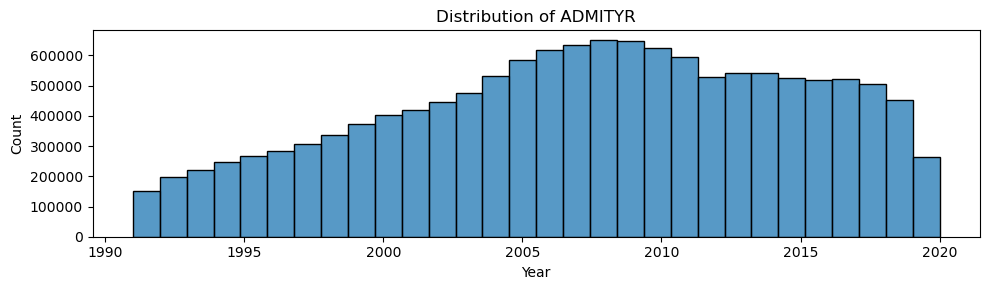

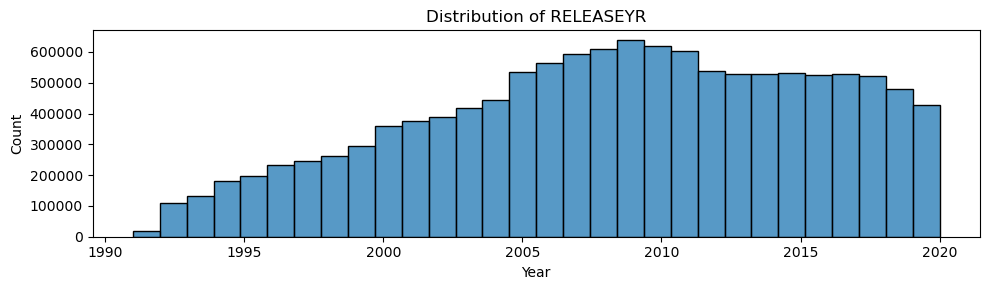

In [10]:
# Year distributions for columns remaining in the analysis
for col in ["ADMITYR", "RELEASEYR"]:
    plt.figure(figsize=(10, 3))
    vals = df[col].dropna().astype(int)
    bins = vals.max() - vals.min() + 1
    sns.histplot(vals, bins=bins, kde=False)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [11]:
# Post-filter missingness check
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Missing values after cleaning (%):")
print(missing_pct[missing_pct > 0].round(2))

Missing values after cleaning (%):
RELTYPE       12.03
RACE           8.87
AGERELEASE     7.61
RELEASEYR      7.26
ADMTYPE        2.25
dtype: float64


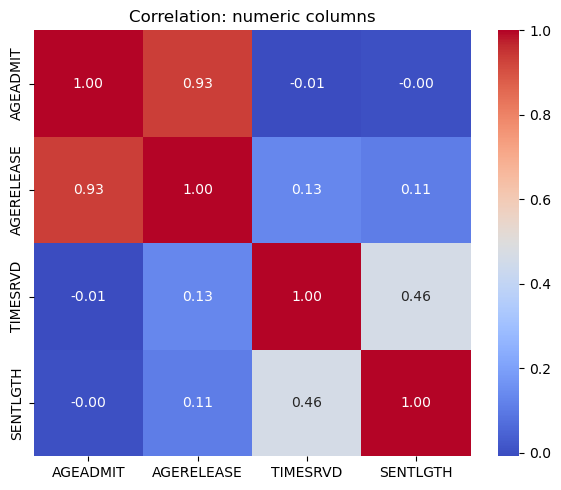

In [12]:
# Correlation heatmap for numeric columns only
num_cols = ["AGEADMIT", "AGERELEASE", "TIMESRVD", "SENTLGTH"]
plt.figure(figsize=(6, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation: numeric columns")
plt.tight_layout()
plt.show()

In [13]:
# Save cleaned file
df.to_parquet("../data/processed/NCRP_1991_2020_clean.parquet", index=False)
print(f"Saved cleaned file. Final shape: {df.shape}")

Saved cleaned file. Final shape: (13407592, 14)
